In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
import sys
import os
root = '/projects/p32813/blume_capel'

In [2]:
def combined_error(group, field, se_field):
        N = len(group)
        s = group[field].std()
        sigma_i = group[se_field]
        # combine in quadrature
        total_error = np.sqrt((s**2) / N + (sigma_i**2).sum() / (N**2))
        # total_error = s / np.sqrt(N)
        return pd.Series({
            "mean": group[field].mean(),
            "std": s,
            "mean_se": sigma_i.mean(),
            "error": total_error
    })

In [3]:
# Magnet Susceptibility
def getExponent(filename, q_name, se_name, n=3):
    df_raw = pd.read_csv(filename, sep=',')
    df = df_raw.groupby("L")[[q_name, se_name]].apply(lambda x: combined_error(x, q_name, se_name)).reset_index()                      
        
    df['logL'] = np.log(df['L'])
    df['1/L'] = 1/df['L']
    df['logX'] = np.log(df['mean'])
    df['SE_logX'] = df['error'] / df['mean']

    base = df.shape[0]-2-n
    invL = np.zeros(n)
    exp = np.zeros(n)
    error = np.zeros(n)

    for i in range(base, base+n):
        invL[i-base] = df['1/L'].iloc[i+2]
        exp[i-base] = (df['logX'].iloc[i+2] - df['logX'].iloc[i]) / (df['logL'].iloc[i+2] - df['logL'].iloc[i])
        error[i-base] = np.sqrt((df['SE_logX'].iloc[i+2])**2 + (df['SE_logX'].iloc[i])**2) / (df['logL'].iloc[i+2] - df['logL'].iloc[i])
    return (invL, exp, error)

def getB(filename, n=3):
    df_raw = pd.read_csv(filename, sep=',')
    df = df_raw.groupby("L")[["corner_contribution", "standard_error"]].apply(lambda x: combined_error(x, "corner_contribution", "standard_error")).reset_index()
    df['l'] = df['L'] / 2
    df['logl'] = np.log(df['l'])
    df['1/l'] = 1/df['l']

    base = df.shape[0]-2-n
    invL = np.zeros(n)
    b = np.zeros(n)
    error = np.zeros(n)

    for i in range(base, base+n):
        invL[i-base] = df['logl'].iloc[i+2]*df['1/l'].iloc[i+2]
        b[i-base] = (df['mean'].iloc[i+2] - df['mean'].iloc[i]) / (df['logl'].iloc[i+2] - df['logl'].iloc[i])
        error[i-base] = np.sqrt((df['error'].iloc[i+2])**2 + (df['error'].iloc[i])**2) / (df['logl'].iloc[i+2] - df['logl'].iloc[i])
    return (invL, b, error)

In [13]:
def getFit(invL, observable, error, minx = np.log(8)/8):
    fit, cov = np.polyfit(invL, observable, 1, w=1/error**2, cov=True)
    x = np.linspace(0, minx, 100)
    y = np.polyval(fit, x)
    return (x, y, cov[0][0])
    
def plotFss(ax, invL, observable, error, observable_name, dataset_name, expected, 
            colors=('lightgray', 'dimgray', 'black'), name='', zoom=0.1):
    maxy = max(observable)
    miny = min(observable)
    maxy = max(maxy, expected)
    miny = min(miny, expected)
    dy = maxy-miny
    maxheight = maxy + zoom*dy
    minheight = miny - zoom*dy
    x, y, yerr = getFit(invL, observable, error)
    
    # Axes
    ax.vlines((0,), minheight, maxheight, linestyle='solid', color=colors[0])
    ax.hlines((expected,), 0, 1/6, linestyle='solid', color=colors[0], label=f'Expected Answer {name}')

    ax.plot(x, y, linestyle='dashed', linewidth=1, color=colors[2])
    ax.errorbar(invL, observable, yerr=error, linestyle='none', fmt='.', capsize=3, color=colors[2])

    # Final ans
    ax.errorbar([0], [y[0]], [yerr], marker='D', markersize=3, capsize=3, color=colors[1], linestyle='none', label=f'Numerical Answer {name}')

    ax.set_ylim(minheight, maxheight)
    # ax.set_title(f'{dataset_name}\n{observable_name} = {round(y[0], 5)} {r'$\pm$'} {round(yerr, 5)}') 
    ax.set_title(f'{dataset_name}\n{observable_name} = {round(y[0], 5)}') 
    ax.legend(loc='lower right')
    
    return (y[0], yerr)

In [5]:
def plotFss(ax, invL, observable, error, label, 
            color="red"):
    
    miny = min(observable)
    maxy = max(observable)
    ax.errorbar(invL, observable, yerr=error, linestyle='--', fmt='.', capsize=3, color=color, label=label)
    
    return (miny, maxy)

def plotFssSpines(ax, miny, maxy, expected, yname, xname='1/L', minx=1/8, zoom=0.5):
    miny = min(miny, expected)
    maxy = max(maxy, expected)
    dy = maxy - miny
    minh = miny - zoom*dy
    maxh = maxy + zoom*dy

    ax.vlines((0,), minh, maxh, linestyle='solid', color='black')
    ax.hlines((expected,), 0, minx, linestyle='solid', color='black', label=f'Expected Answer {yname}')
    
    ax.set_ylim(minh, maxh)
    ax.set_xlim(0, minx)
    ax.set_xlabel(xname)
    ax.set_ylabel(yname)
    ax.set_title(f'FSS of {yname}') 
    ax.legend(loc='upper right')
    

In [6]:
# Get b for different gamma:
n=10
bs = np.zeros(n)
gammas = np.zeros(n)
for i in range(n):
    file = f'{root}/data/sweep/t3_d3/gap/square/{i}.csv'
    invL, b, error = getB(file, 3)
    _, y, _ = getFit(invL, b, error)
    bs[i] = y[0]
    if i == 0:
        gammas[i] = 90
    else:
        gammas[i] = np.arctan(1/i) * (180/np.pi)
print(bs)
print(gammas)

FileNotFoundError: [Errno 2] No such file or directory: '/projects/p32813/blume_capel/data/sweep/t3_d3/gap/square/0.csv'

In [7]:
# GAMMA IN RADIANS
def calculate_b(gamma, b0):
    # central charge from two line segments
    c = 4 * b0
    return c * total_angle_dependence(gamma)

def angle_dependence(gamma):
        return (1 / 24) * (0
            + np.pi / gamma
            - gamma / np.pi
            + np.pi / (2*np.pi - gamma)
            - (2*np.pi - gamma) / np.pi
        )

def total_angle_dependence(gamma):
    return 2*angle_dependence(gamma) + 2*angle_dependence(np.pi - gamma)
    

FileNotFoundError: [Errno 2] No such file or directory: '/projects/p32813/blume_capel/data/sweep/t3_d3/gap/square/0.csv'

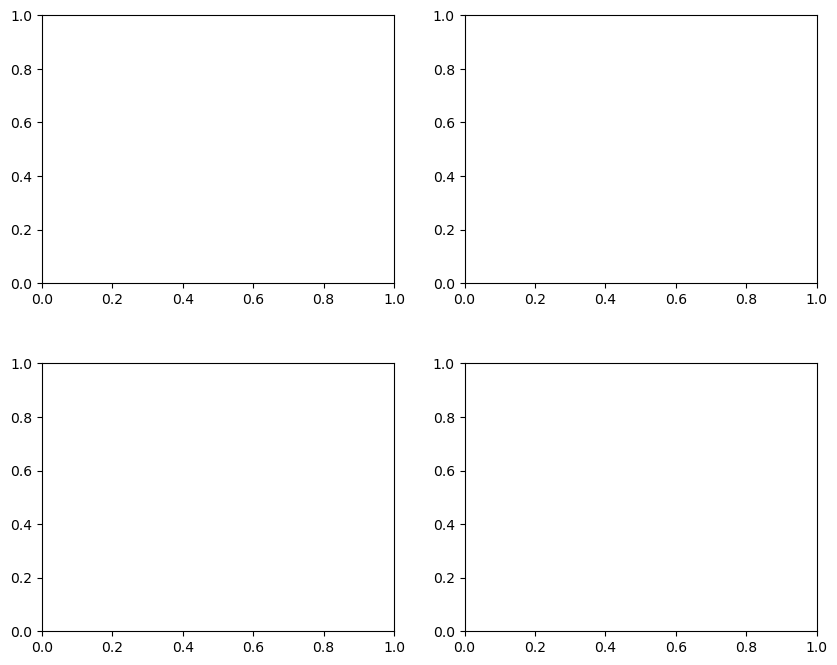

In [8]:
# PLOT SINGLE EXP FROM SINGLE DATASET
b0=0.06688
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.subplots_adjust(hspace=0.3)
name = r'b'
def plotB(ax, file, expected):
    title = rf' Sheared Square FSS of b ($\gamma = {round(gamma, 2)}$)'
    # title = "Line Segment FSS of b"
    zoom = 0.5
    invL, exp, error = getB(file, 3)
    plotFss(ax, invL, exp, error, name, title, expected, zoom=zoom)

for gi in range(4):
    i = gi//2
    j = gi%2
    file = f'{root}/data/sweep/t3_d3/gap/square/{gi}.csv'
    # file = f'{root}/data/sweep/t3_d3/gap/fk.txt'
    # file = f'{root}/data/sweep/t3_d4/gap/spin.txt'
    if gi == 0:
        gamma = np.pi/2
    else:
        gamma = np.arctan(1/gi)
    expected = calculate_b(gamma, b0)
    plotB(axs[i, j], file, expected)


fig.supylabel(f'2-point estimate of {name}')
fig.supxlabel('log(l)/l')
plt.show()

In [ ]:
# PLOTTING MULTIPLE DATASETS
data_root = '/projects/p32813/blume_capel/data/sweep'
# EXPECTED=0.343774677/4
EXPECTED = 0.2
# EXPECTED = 1.85
# EXPECTED = -0.075
# x_name, error_name = ("m", "se_m")
name = r'$\beta/\nu$'
name = 'b'
x_max = np.log(8)/8


points = (
    (2,3),
    (3,3),
    (1,3),
    (2,4),
    (2,2))
points = (
    (1,3.5),
    (2,3.5),
    (3,3.5),
    (4,3.5),
    (3,3)
         )
points = (
    (3,3),
    (4,3),
    (2,3),
    (3, 3.5),
    (3, 2),
    (3,3)
)

labels = ("(3, 3)",
          "(4, 3)",
          "(2, 3)",
          "(3, 3.5)",
          "(3, 2)",
          "OLD",
         )

points = (
    (3, 3),
    (3.5, 3),
    (2.5, 3),
    (3,3.5),
    (3, 2.5),
)

labels = ("Center", "T+", "T-", "D+", "D-", "OLD")

colors = (
    'black',
    'red',
    'orange',
    'cornflowerblue',
    'blue',
    'green',
    'black',
    'black',
    'green',
    'orange',
    'red',
    'gray'
)

miny, maxy = 100, -100
desired = (0,1,2,3,4)
for i in desired:
    ti, di = points[i]
    filename = f"{data_root}/t{ti}_d{di}/gap/square/spin/4.csv"
    label=labels[i]
    # invL, exponent, error = getExponent(filename, x_name, error_name, 5)
    invL, exponent, error = getB(filename, 3)
    print(invL, exponent)
    curr_miny, curr_maxy = plotFssMulti(plt.gca(), invL, exponent, error, label, color=colors[i])
    miny = min(miny, curr_miny)
    maxy = max(maxy, curr_maxy)
    X, Y, _ = getFit(invL, exponent, error, x_max)
    # print(label, Y[0])
    plt.plot(X, Y, color=colors[i], alpha=0.5)
    
plotFssSpines(plt.gca(), miny, maxy, EXPECTED, name, "1/L", x_max, zoom=0.05)

In [ ]:
invL, b, error = getB('./data/tc-10-8/gap/spin.txt')
plotFss(plt.gca(), invL, b, error, 'b', 'Tricritical b', 0.739320704/16,
        colors=('lightcoral', 'firebrick', 'red'), name='Spin')
invL, b, error = getB('./data/tc-10-8/gap/fk.txt')
plotFss(plt.gca(), invL, b, error, 'b', 'Tricritical b', 0.343774677/16, 
        colors=('lightsteelblue', 'royalblue', 'blue'), name='FK')

# plt.title(f'FSS of {r'$\gamma/\nu$'}')
plt.ylabel(f'2-point estimate of b')
plt.xlabel('1/L')
plt.show()

In [9]:
# Getting Numbers
def getFit(invL, observable, error):
    maxheight = max(observable) * 1.2
    minheight = min(observable) * 0.8
    fit, cov = np.polyfit(invL, observable, 1, w=1/error, cov=True)
    yerr = cov[0][0]
    x = np.linspace(0, 1/6, 100)
    y = np.polyval(fit, x)
    
    return y[0]

def getMassSusceptibility(group):
    group['logL'] = np.log(group['L'])
    group['1/L'] = 1/group['L']
    group['logX'] = np.log(group['magnetic_susceptibility'])
    group['SE_logX'] = group['standard_error'] / group['magnetic_susceptibility']
    
    n = group.shape[0]-2
    m = 0
    invL = np.zeros(n-m)
    gamma = np.zeros(n-m)
    error = np.zeros(n-m)

    for i in range(m,n):
        invL[i-m] = group['1/L'].iloc[i]
        gamma[i-m] = (group['logX'].iloc[i+2] - group['logX'].iloc[i]) / (group['logL'].iloc[i+2] - group['logL'].iloc[i])
        error[i-m] = np.sqrt((group['SE_logX'].iloc[i+2])**2 + (group['SE_logX'].iloc[i])**2) / (group['logL'].iloc[i+2] - group['logL'].iloc[i])

    return pd.Series({
            "fit": getFit(invL, gamma, error)
    })

def mass(filename):
    df_raw = pd.read_csv(filename, sep=',')
    df = df_raw.groupby("batch").apply(getMassSusceptibility).reset_index()                      
    return (df['fit'].mean(), df['fit'].std())
    

In [11]:
def load_means_by_L(filename: str) -> pd.DataFrame:
    df_raw = pd.read_csv(filename)
    df = (
        df_raw.groupby("L", as_index=False)[["corner_contribution", "standard_error"]]
              .apply(lambda g: combined_error(g, "corner_contribution", "standard_error"))
              .reset_index(drop=True)
    )
    df["L"] = df["L"].astype(int)
    df["l"] = df["L"]//2
    df["logl"] = np.log(df["l"].astype(float))
    return df


def b_for_pair(dfL: pd.DataFrame, L1: int, L2: int) -> tuple[float, float]:
    """Compute b and its propagated error for (L1, L2)."""
    row1 = dfL.loc[dfL["L"] == L1]
    row2 = dfL.loc[dfL["L"] == L2]
    if row1.empty or row2.empty:
        return (np.nan, np.nan)

    m1, e1, log1 = float(row1["mean"].iloc[0]), float(row1["error"].iloc[0]), float(row1["logl"].iloc[0])
    m2, e2, log2 = float(row2["mean"].iloc[0]), float(row2["error"].iloc[0]), float(row2["logl"].iloc[0])

    denom = (log2 - log1)
    b = (m2 - m1) / denom
    err = np.sqrt(e1**2 + e2**2) / abs(denom)
    return (b, err)

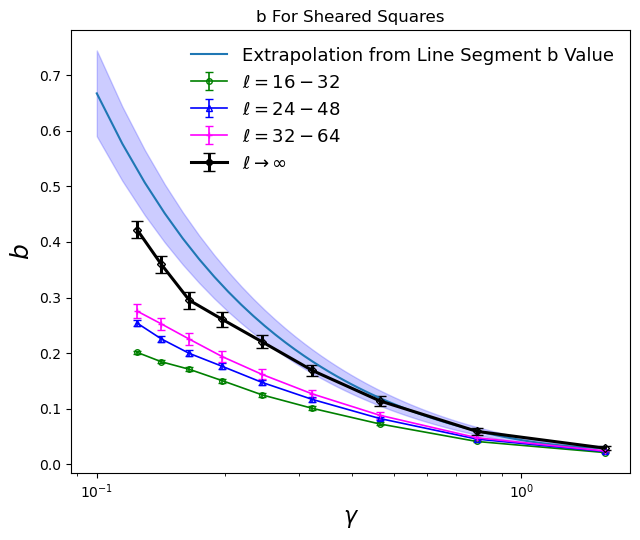

In [30]:
# --- Main aggregation across gamma files ---
dirname="/projects/p32813/blume_capel/data/sweep/t3_d3/gap/square/spin"
error_datasets=(
    ("t3_d3.5",
     "t3_d2.5",
     "t3.5_d3",
     "t2.5_d3")
)

pairs = [(16,32), (24,48), (32,64)]
labels = {(16,32):"32", (24,48):"48", (32,64):"64" }
b0 = 0.06688
db = 0.007736

results = {p: {"gamma": [], "b": [], "err": []} for p in pairs}
results_extrap = {"gamma": [], "b": [], "err": []}


for k in range(9):
    fname = f"{dirname}/{k}.csv"
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Missing {fname} in current directory")

    df_raw = pd.read_csv(fname)
    gamma = float(df_raw["gamma"].iloc[0])
    dfL = load_means_by_L(fname)

    # --- pairwise estimates ---
    for p in pairs:
        b, _ = b_for_pair(dfL, p[0], p[1])
        results[p]["gamma"].append(gamma)
        results[p]["b"].append(b)
        results[p]["err"].append(0)

     # --- extrapolated estimate ---
    invL, exponent, error = getB(fname, 3)
    _, y, _ = getFit(invL, exponent, error)
    b_inf, err_inf = y[0], 0
    results_extrap["gamma"].append(gamma)
    results_extrap["b"].append(b_inf)
    results_extrap["err"].append(err_inf)

    # --- calculating errors ---
    err_df_raw = list()
    for dataset in error_datasets:
        fname_err = f"/projects/p32813/blume_capel/data/sweep/{dataset}/gap/square/spin/{k}.csv"
        err_dfL = load_means_by_L(fname_err)
        for p in pairs:
            b, _ = b_for_pair(err_dfL, p[0], p[1])
            error = abs(results[p]["b"][k] - b)
            results[p]["err"][k] = max(error, results[p]["err"][k])
        # Extrapolated error
        invL, exponent, error = getB(fname_err, 3)
        _, y, _ = getFit(invL, exponent, error)
        b_inf = y[0]
        err = abs(results_extrap["b"][k] - b_inf)
        results_extrap["err"][k] = max(results_extrap["err"][k], err)
 
# --- Plot: x=gamma, y=b with 5 lines ---
styles = {
    (16,32): dict(marker='o', color='green', fillstyle='none'),
    (24,48): dict(marker='^', color='blue', fillstyle='none'),
    (32,64): dict(marker='+', color='magenta', fillstyle='none'),
}

labels = {
    (16,32): r"$\ell = 16-32$",
    (24,48): r"$\ell = 24-48$",
    (32,64): r"$\ell = 32-64$",
}

fig, ax = plt.subplots(figsize=(6.5, 5.5))

for pair, style in styles.items():
    g = np.array(results[pair]["gamma"]) * (np.pi/180)
    b = np.array(results[pair]["b"])
    e = np.array(results[pair]["err"])

    order = np.argsort(g)
    g, b, e = g[order], b[order], e[order]

    ax.errorbar(
        g, b, yerr=e,
        linestyle='-', linewidth=1.2,
        markersize=4,
        capsize=3,
        label=labels[pair],
        **style
    )
    
# --- Infinite L limit ---
g_inf = np.array(results_extrap["gamma"]) * (np.pi/180)
b_inf = np.array(results_extrap["b"])
e_inf = np.array(results_extrap["err"])

order = np.argsort(g_inf)
g_inf, b_inf, e_inf = g_inf[order], b_inf[order], e_inf[order]

ax.errorbar(
    g_inf, b_inf, yerr=e_inf,
    linestyle='-',
    linewidth=2.2,
    marker='D',
    markersize=4,
    fillstyle='none',
    color='black',
    capsize=4,
    label=r"$\ell \to \infty$"
)

# Extrapolation from line segment
X = np.linspace(np.pi/2, 0.1, 100)
plt.plot(X, calculate_b(X, b0), label="Extrapolation from Line Segment b Value")
ax.fill_between(X, calculate_b(X, b0-db), calculate_b(X, b0+db), color='blue', alpha=0.2)

# --- Axes formatting (this is the key part) ---
ax.set_xscale("log")
ax.set_xlabel(r"$\gamma$", fontsize=16)
ax.set_ylabel(r"$b$", fontsize=18)
'''
ax.tick_params(
    axis='both',
    which='major',
    labelsize=14,
    width=1.6,
    length=6
)

ax.tick_params(
    axis='both',
    which='minor',
    width=1.2,
    length=3
)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)
'''
ax.legend(
    fontsize=13,
    title_fontsize=14,
    frameon=False
)
plt.title("b For Sheared Squares")

plt.tight_layout()
plt.show()

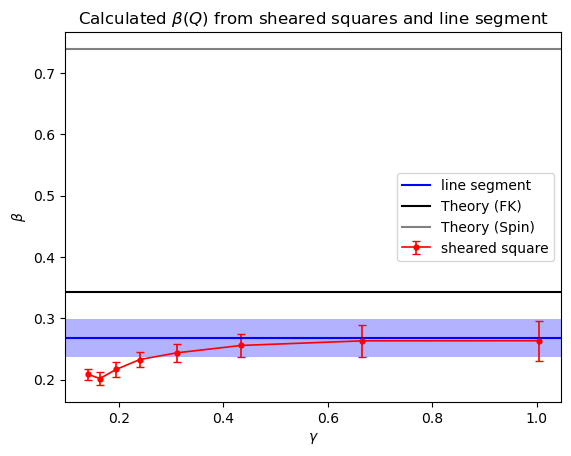

In [31]:
import matplotlib.patches as patches
error_datasets=(
    ("t3_d3.5",
     "t3_d2.5",
     "t3.5_d3",
     "t2.5_d3")
)
# --- Beta consistency plot ---
def get_beta(fname, gamma):
    invL, exponent, error = getB(fname, 3)
    _, y, _ = getFit(invL, exponent, error)
    
    b = y[0]
    beta = b / total_angle_dependence(gamma)
    return beta

n=8
dirname="/projects/p32813/blume_capel/data/sweep/t3_d3/gap/square/spin"
results = {"gamma": np.zeros(n), "beta": np.zeros(n), "err": np.zeros(n)}
for k in range(n):
    fname = f"{dirname}/{k}.csv"
    df_raw = pd.read_csv(fname)
    
    gamma = float(df_raw["gamma"].iloc[0]) * (np.pi / 180)
    beta = get_beta(fname, gamma)

    results["gamma"][k] = gamma
    results["beta"][k] = beta

    # --- calculating errors ---
    err_df_raw = list()
    for dataset in error_datasets:
        fname = f"/projects/p32813/blume_capel/data/sweep/{dataset}/gap/square/spin/{k}.csv"
        beta = get_beta(fname, gamma)
        
        err = abs(results["beta"][k] - beta)
        results["err"][k] = max(results["err"][k], err)

plt.errorbar(
        np.arctan(results["gamma"]), results["beta"], yerr=results["err"],
        linestyle='-', linewidth=1.2,
        marker='.', markersize=7,
        capsize=3,
        label="sheared square",
        color='red'
    )

beta0 = 0.06688 * 4
dbeta = 0.007736 * 4

rect = patches.Rectangle((0, beta0-dbeta), np.pi/2, dbeta*2, 
                         linewidth=2, 
                         edgecolor='none', 
                         facecolor='blue', alpha=0.3)
plt.axhline(beta0, 0, np.pi/2, label="line segment", color='blue')
plt.gca().add_patch(rect)
plt.axhline(0.343774677, 0, np.pi/2, label="Theory (FK)", color="black")
plt.axhline(0.739320704, 0, np.pi/2, label="Theory (Spin)", color="gray")

plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\beta$')
plt.title(r"Calculated $\beta(Q)$ from sheared squares and line segment")
plt.legend()
plt.show()
            